In [2]:
# --- Imports ---
import json
import ast
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

# --- Config ---
BASE_DIR = Path("./../../data/clean_bugtrap")  # root folder with one subdir per algorithm
LIST_COLS = ["qpos", "qvel", "control", "running_cost"]





# for algo in ["mppi", "cem", "mtp"]:
#     arr_sum = None
#     for i in [0,1,2,3,4]:
#         path = f"../data/headless_bugtrap_{algo}/bugtrap_seed_{i}.pkl"
#         with open(path, "rb") as f:
#             obj = pickle.load(f)

#         arr = np.asarray(obj).T

#         if arr.ndim > 2:
#             arr = arr.sum(axis=tuple(range(arr.ndim - 2)))

#         if arr_sum is None:
#             arr_sum = arr.copy()
#         else:
#             arr_sum += arr   # accumulate




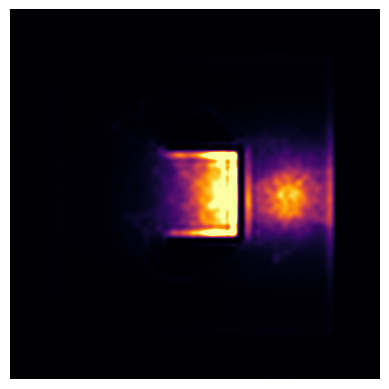

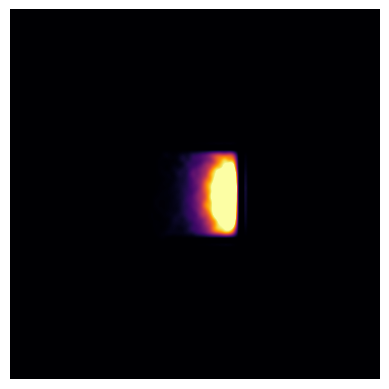

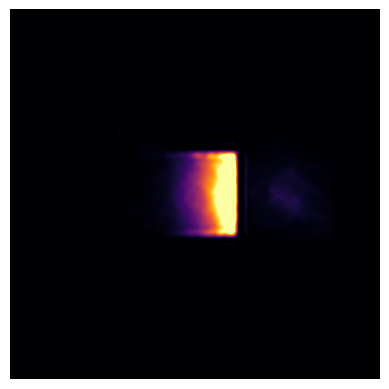

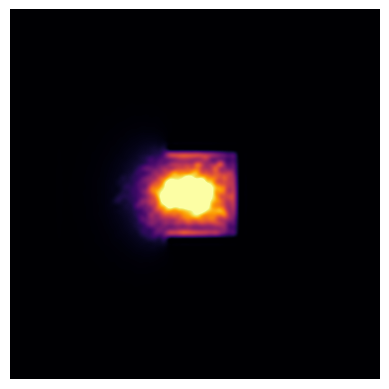

In [23]:
for algo in ["mtp", "cem", "ps", "mppi"]:
    arr_sum = None
    for seed in [0, 1, 2, 10, 11, 12]:
        path = f"./../../data/clean_bugtrap/{algo}/clean_seed_{seed}_bins.pkl"
        with open(path, "rb") as f:
            obj = pickle.load(f)

        arr = np.asarray(obj).T

        if arr.ndim > 2:
            arr = arr.sum(axis=tuple(range(arr.ndim - 2)))

        if arr_sum is None:
            arr_sum = arr.copy()
        else:
            arr_sum += arr   # accumulate

    # --- Plot heatmap ---
    vmin, vmax = np.percentile(arr_sum, [1, 99])  # tune percentiles
    ax = plt.subplot(1, 1, 1)
    ax.imshow(arr_sum, origin="lower", cmap="inferno", interpolation="lanczos", vmin=vmin, vmax=vmax)
    ax.grid(False)  
    ax.set_axis_off()
    plt.show()
    
    # save figure as pdf
    fig = ax.get_figure()
    fig.savefig(f"./bugtrap_escape_{algo}_heatmap.pdf", bbox_inches="tight", pad_inches=0)

(80, 80)


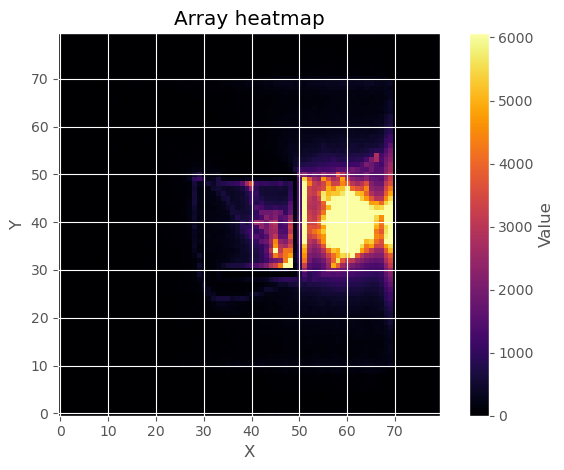

In [55]:
# load pkl files
log = pickle.load(open("./../../data/clean_bugtrap/mtp/clean_seed_4.pkl", "rb"))
states = np.array(log).T
print(states.shape)

# --- Plot heatmap ---
vmin, vmax = np.percentile(states, [2, 98])  # tune percentiles
plt.imshow(states, origin="lower", cmap="inferno", interpolation="nearest", vmin=vmin, vmax=vmax)
plt.colorbar(label="Value")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Array heatmap")
plt.tight_layout()
plt.show()

(80, 80)


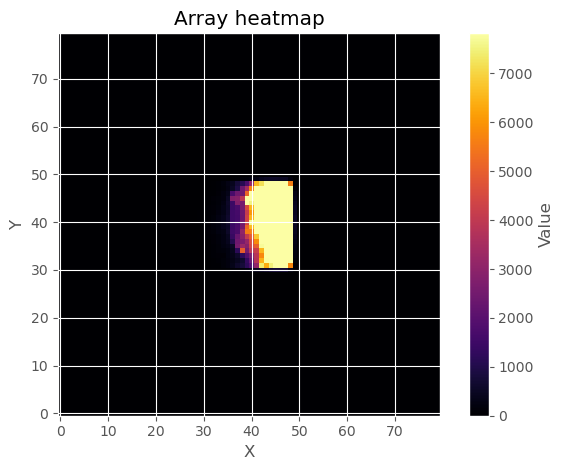

In [57]:
# load pkl files
log = pickle.load(open("./../../data/clean_bugtrap/cem/clean_seed_4.pkl", "rb"))
states = np.array(log).T
print(states.shape)

# --- Plot heatmap ---
vmin, vmax = np.percentile(states, [2, 98])  # tune percentiles
plt.imshow(states, origin="lower", cmap="inferno", interpolation="nearest", vmin=vmin, vmax=vmax)
plt.colorbar(label="Value")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Array heatmap")
plt.tight_layout()
plt.show()